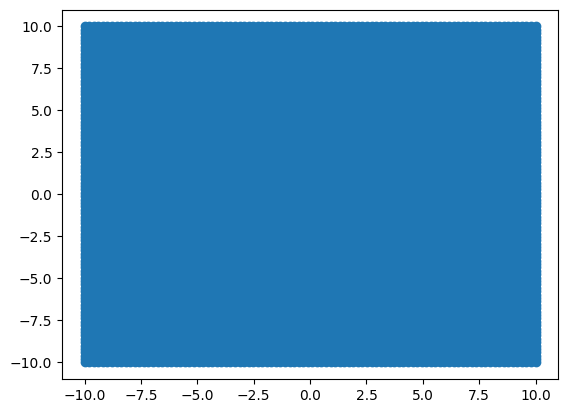

In [14]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(-10, 10, 100)
ys = np.linspace(-10, 10, 100)

X,Y=  np.meshgrid(xs,ys)  # 生成网格点坐标矩阵的函数，常用于场景二维或者多维坐标网格

plt.scatter(X,Y)



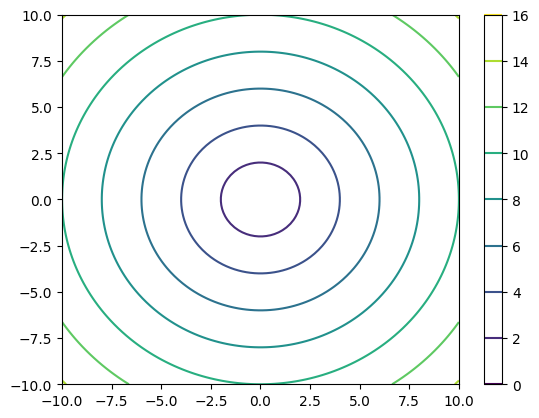

In [15]:

# 计算Z轴的所有值   (X^2+Y^2)^1/2 =Z
Z = np.sqrt(X**2+Y**2)

# 绘制等高线
# plt.contourf(X,Y,Z)  #绘制等高线  颜色越深表示值越小  中间的黑色表示0
plt.contour(X,Y,Z)   #绘制等高线
plt.colorbar()

[[1.9 1.2]
 [1.5 2.1]
 [1.9 0.5]
 [1.5 0.9]
 [0.9 1.2]
 [1.1 1.7]
 [1.4 1.1]
 [3.2 3.2]
 [3.7 2.9]
 [3.2 2.6]
 [1.7 3.3]
 [3.4 2.6]
 [4.1 2.3]
 [3.  2.9]
 [3.3 1.2]
 [3.8 0.9]
 [3.3 0.6]
 [2.8 1.3]
 [3.5 0.6]
 [4.2 0.3]
 [3.1 0.9]]
先验概率： 0.3333333333333333 0.3333333333333333 0.3333333333333333


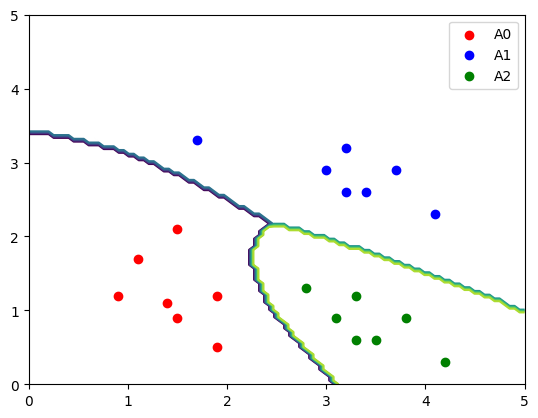

In [16]:
import numpy as np

# 1.散点输入
class1_points = np.array([[1.9, 1.2],
                          [1.5, 2.1],
                          [1.9, 0.5],
                          [1.5, 0.9],
                          [0.9, 1.2],
                          [1.1, 1.7],
                          [1.4, 1.1]])

class2_points = np.array([[3.2, 3.2],
                          [3.7, 2.9],
                          [3.2, 2.6],
                          [1.7, 3.3],
                          [3.4, 2.6],
                          [4.1, 2.3],
                          [3.0, 2.9]])

class3_points = np.array([[3.3, 1.2],
                          [3.8, 0.9],
                          [3.3, 0.6],
                          [2.8, 1.3],
                          [3.5, 0.6],
                          [4.2, 0.3],
                          [3.1, 0.9]])

# 2、数据预处理
xs = np.concatenate((class1_points,class2_points,class3_points))
print(xs)


# 3、计算先验概率 A0为类别为0的事件  A1为类别1的事件 A2为类别2的事件
P_A0 = len(class1_points)/len(xs)
P_A1 = len(class2_points)/len(xs)
P_A2 = len(class3_points)/len(xs)
print('先验概率：',P_A0,P_A1,P_A2)

# 4、计算条件概率
# 计算A0事件中的均值、协方差矩阵
mean_A0 = np.mean(class1_points,axis=0)
cov_A0 = np.cov(class1_points.T)

# 计算A1事件中的均值、协方差矩阵
mean_A1 = np.mean(class2_points,axis=0)
cov_A1 = np.cov(class2_points.T)

# 计算A2事件中的均值、协方差矩阵
mean_A2 = np.mean(class3_points,axis=0)
cov_A2 = np.cov(class3_points.T)


# 绘制等高线
import matplotlib.pyplot as plt
xs = np.linspace(0, 5, 100)
ys = np.linspace(0, 5, 100)
X,Y=  np.meshgrid(xs,ys)  # 生成网格点坐标矩阵的函数，常用于场景二维或者多维坐标网格
pts = np.stack((X.ravel(),Y.ravel()),axis=1)
# print(pts)
Z_Labels = []
for pt in pts:
    n = len(pt)
    P_B_A0 = 1 / ((2 * np.pi) ** (n / 2)) * np.sqrt(np.linalg.det(cov_A0))
    P_B_A0 = P_B_A0 * np.exp(-0.5 * np.dot(np.dot((pt - mean_A0).T, np.linalg.inv(cov_A0)), (pt - mean_A0)))

    # 计算A1事件中的条件概率 林奈艾尔吉
    P_B_A1 = 1 / ((2 * np.pi) ** (n / 2)) * np.sqrt(np.linalg.det(cov_A1))
    P_B_A1 = P_B_A1 * np.exp(-0.5 * np.dot(np.dot((pt - mean_A1).T, np.linalg.inv(cov_A1)), (pt - mean_A1)))

    P_B_A2 = 1 / ((2 * np.pi) ** (n / 2)) * np.sqrt(np.linalg.det(cov_A2))
    P_B_A2 = P_B_A2 * np.exp(-0.5 * np.dot(np.dot((pt - mean_A2).T, np.linalg.inv(cov_A2)), (pt - mean_A2)))

    P_A0_B = P_B_A0 * P_A0
    P_A1_B = P_B_A1 * P_A1
    P_A2_B = P_B_A2 * P_A2
    # print('后验概率A0：', P_A0_B)
    # print('后验概率A1：', P_A1_B)
    # print('后验概率A2：', P_A2_B)
    Z_Labels.append( np.argmax([P_A0_B,P_A1_B,P_A2_B]))

plt.scatter(class1_points[:,0],class1_points[:,1],c='r',label='A0')
plt.scatter(class2_points[:,0],class2_points[:,1],c='b',label='A1')
plt.scatter(class3_points[:,0],class3_points[:,1],c='g',label='A2')
Z_Labels = np.array(Z_Labels).reshape(X.shape)
plt.contour(X,Y,Z_Labels)   #绘制等高线

plt.legend ()
plt.show()